In [1]:
import numpy as np
import pandas as pd

models = [
    "all-MiniLM-L6-v2",
    "all-mpnet-base-v2",
    "paraphrase-MiniLM-L3-v2",
    "roberta-large-nli-stsb-mean-tokens",
    "distilbert-base-nli-stsb-mean-tokens"
]

data = pd.DataFrame({
    "Model": models,
    "STS_B_Score":     [88.5, 89.3, 84.2, 90.1, 86.4],
    "Spearman_Corr":   [0.814, 0.827, 0.771, 0.831, 0.793],
    "Inference_Time":  [14, 55, 6, 120, 30],
    "Model_Size":      [22, 109, 17, 355, 66]
})

print("\n=== Decision Matrix (raw data) ===")
print(data.to_string(index=False))

matrix = data.iloc[:, 1:].values.astype(float)
norm   = matrix / np.sqrt((matrix ** 2).sum(axis=0))

weights = np.array([0.35, 0.30, 0.20, 0.15])

print("\n=== Weights (how much each criterion matters) ===")
criteria = ["STS_B_Score", "Spearman_Corr", "Inference_Time", "Model_Size"]
labels   = [
    "<-- accuracy on STS benchmark matters most",
    "<-- rank correlation is also very important",
    "<-- speed matters for real-world use",
    "<-- smaller is better for deployment"
]
for c, w, l in zip(criteria, weights, labels):
    print(f"{c:<20}: {w}  {l}")

weighted = norm * weights

# Ideal worst = opposite
ideal_best = np.array([
    weighted[:, 0].max(),
    weighted[:, 1].max(),
    weighted[:, 2].min(),
    weighted[:, 3].min()
])

ideal_worst = np.array([
    weighted[:, 0].min(),
    weighted[:, 1].min(),
    weighted[:, 2].max(),
    weighted[:, 3].max()
])

dist_best  = np.sqrt(((weighted - ideal_best)  ** 2).sum(axis=1))
dist_worst = np.sqrt(((weighted - ideal_worst) ** 2).sum(axis=1))

score = dist_worst / (dist_best + dist_worst)

data["TOPSIS_Score"] = score
data["Rank"]         = data["TOPSIS_Score"].rank(ascending=False)

print("\n=== Final TOPSIS Rankings ===")
result = data[["Model", "TOPSIS_Score", "Rank"]].sort_values(by="Rank")
print(result.to_string(index=False))


=== Decision Matrix (raw data) ===
                               Model  STS_B_Score  Spearman_Corr  Inference_Time  Model_Size
                    all-MiniLM-L6-v2         88.5          0.814              14          22
                   all-mpnet-base-v2         89.3          0.827              55         109
             paraphrase-MiniLM-L3-v2         84.2          0.771               6          17
  roberta-large-nli-stsb-mean-tokens         90.1          0.831             120         355
distilbert-base-nli-stsb-mean-tokens         86.4          0.793              30          66

=== Weights (how much each criterion matters) ===
STS_B_Score         : 0.35  <-- accuracy on STS benchmark matters most
Spearman_Corr       : 0.3  <-- rank correlation is also very important
Inference_Time      : 0.2  <-- speed matters for real-world use
Model_Size          : 0.15  <-- smaller is better for deployment

=== Final TOPSIS Rankings ===
                               Model  TOPSIS_Score  R

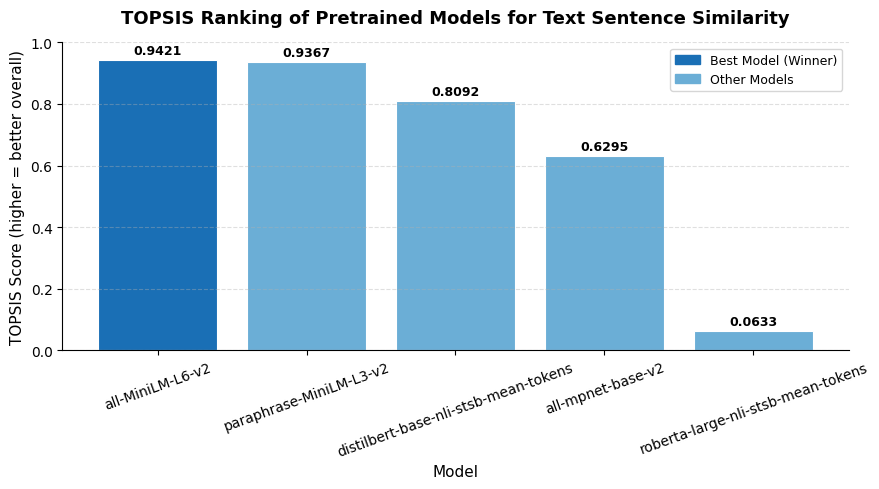

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sorted_data = data.sort_values(by="TOPSIS_Score", ascending=False)

colors = ['#1a6fb5' if i == 0 else '#6baed6' for i in range(len(sorted_data))]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(sorted_data["Model"], sorted_data["TOPSIS_Score"],
              color=colors, edgecolor='white', linewidth=0.8)

for bar, score in zip(bars, sorted_data["TOPSIS_Score"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title("TOPSIS Ranking of Pretrained Models for Text Sentence Similarity",
             fontsize=13, fontweight='bold', pad=14)
ax.set_ylabel("TOPSIS Score (higher = better overall)", fontsize=11)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylim(0, 1.0)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

best_patch = mpatches.Patch(color='#1a6fb5', label='Best Model (Winner)')
rest_patch = mpatches.Patch(color='#6baed6', label='Other Models')
ax.legend(handles=[best_patch, rest_patch], fontsize=9)

plt.tight_layout()
plt.savefig('topsis_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

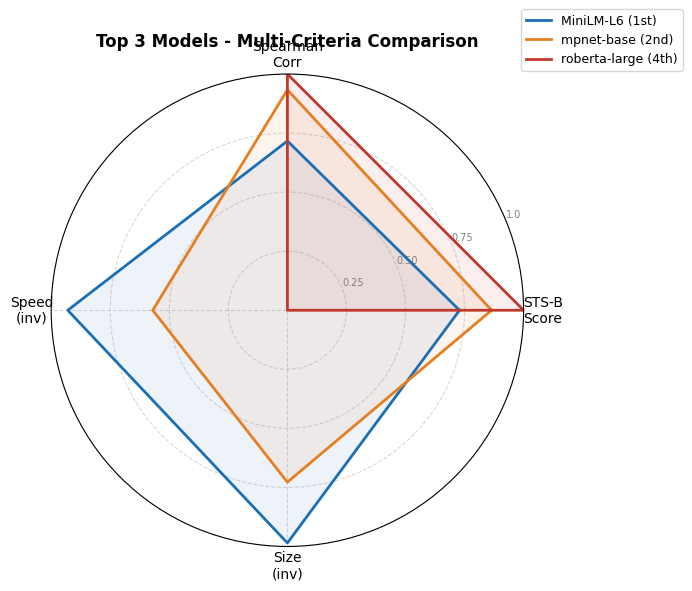

In [3]:
import numpy as np
import matplotlib.pyplot as plt

categories = ['STS-B\nScore', 'Spearman\nCorr', 'Speed\n(inv)', 'Size\n(inv)']
N = len(categories)

def normalize_col(values, higher_is_better=True):
    """Normalise a list of values to 0-1 range. Invert if lower is better."""
    mn, mx = min(values), max(values)
    if mx == mn:
        return [0.5] * len(values)
    norm = [(v - mn) / (mx - mn) for v in values]
    if not higher_is_better:
        norm = [1 - x for x in norm]
    return norm

stsb  = normalize_col([88.5, 89.3, 84.2, 90.1, 86.4], True)
spear = normalize_col([0.814, 0.827, 0.771, 0.831, 0.793], True)
speed = normalize_col([14, 55, 6, 120, 30], False)   # lower time = higher score
size  = normalize_col([22, 109, 17, 355, 66], False)  # smaller = higher score

model_labels = ['MiniLM-L6 (1st)', 'mpnet-base (2nd)', 'roberta-large (4th)']
indices = [0, 1, 3]  # indices in the original data list
radar_data = [[stsb[i], spear[i], speed[i], size[i]] for i in indices]

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

colors_radar = ['#1a6fb5', '#e67e22', '#c0392b']

fig, ax = plt.subplots(figsize=(7, 6), subplot_kw=dict(polar=True))
for vals, label, color in zip(radar_data, model_labels, colors_radar):
    vals_plot = vals + vals[:1]
    ax.plot(angles, vals_plot, color=color, linewidth=2, label=label)
    ax.fill(angles, vals_plot, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.0'], fontsize=7, color='gray')
ax.set_title("Top 3 Models - Multi-Criteria Comparison",
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('topsis_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()